<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/3D_Cow_CFD_Visualization_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# Install necessary libraries
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!uv pip install -q -U "numpy>=2.3.5,<2.4" "scipy>=1.16,<1.17" mpi4py pyfr k3d cupy-cuda12x trimesh matplotlib rtree embreex ipywidgets

from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
# Alternative installation script
# !uv pip install git+https://github.com/PyFR/PyFR.git k3d cupy-cuda12x trimesh numpy matplotlib ipython rtree

In [ ]:
"""Render GPU potential flow around a cow mesh with PyFR and K3D.

PyFR supplies the native simulation configuration structure. CuPy evaluates
the Cartesian GPU potential-flow approximation, Trimesh supplies the imported
three-dimensional boundary representation, and K3D renders velocity-colored
streamlines around the solid geometry.
"""

from __future__ import annotations

import html
import importlib.metadata
import pathlib
import urllib.request
from dataclasses import dataclass

import cupy as cp
import cupyx.scipy.ndimage as gpu_ndimage
import k3d
import matplotlib.pyplot as plt
import numpy as np
import trimesh
from IPython.display import IFrame, display
from k3d.colormaps import matplotlib_color_maps
from pyfr.inifile import Inifile
from trimesh.voxel import VoxelGrid
from trimesh.voxel.encoding import DenseEncoding
from trimesh.voxel.ops import fill_voxelization


# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
MESH_URL = (
    "https://raw.githubusercontent.com/alecjacobson/"
    "common-3d-test-models/master/data/cow.obj"
)
MESH_FILE = "/content/cow.obj"

FLOW_VELOCITY = 1.5
COW_SCALE = 2.0

# Mesh orientation in degrees.
ROTATION_X_DEG = 90.0
ROTATION_Y_DEG = 0.0
ROTATION_Z_DEG = 0.0

# CFD grid.
GRID_SHAPE = (80, 64, 56)

POTENTIAL_ITERATIONS = 1000
JACOBI_RELAXATION = 0.92

# Streamline integration.
INTEGRATION_STEPS = 700
TIME_STEP = 0.035
STREAMLINE_MINIMUM_SPEED = 0.005

# Wind-tunnel dimensions.
MIN_DOMAIN_LENGTH_X = 36.0
MIN_DOMAIN_SPAN_Y = 20.0
MIN_DOMAIN_SPAN_Z = 14.0

DOMAIN_PADDING_X = 7.0
DOMAIN_PADDING_Y = 4.0
DOMAIN_PADDING_Z = 4.0

# Solid representation.
VOXEL_PITCH_SCALE = 0.65
SOLID_DILATION_CELLS = 1

# ---------------------------------------------------
# STREAMLINE SEEDING
# ---------------------------------------------------
# Odd counts guarantee seeds at y = 0 and z = 0.
GLOBAL_SEED_DENSITY_Y = 21
GLOBAL_SEED_DENSITY_Z = 15
GLOBAL_SEED_MARGIN = 0.82

# Dense seed patch aimed directly at the projected cow cross section.
FOCUSED_SEED_DENSITY_Y = 31
FOCUSED_SEED_DENSITY_Z = 23
FOCUSED_SEED_SCALE_Y = 1.35
FOCUSED_SEED_SCALE_Z = 1.35

# ---------------------------------------------------
# WALL-FOLLOWING PHYSICS
# ---------------------------------------------------
# Distance from the surface over which normal velocity is suppressed.
WALL_INFLUENCE_DISTANCE = 1.10

# Minimum clearance retained by streamline particles.
MINIMUM_WALL_CLEARANCE = 0.10

# Number of correction passes for a streamline that enters the voxel shell.
WALL_PROJECTION_PASSES = 3

# ---------------------------------------------------
# K3D
# ---------------------------------------------------
K3D_HEIGHT = 760
K3D_LINE_WIDTH = 0.050

# Reduces K3D payload without altering the CFD integration.
K3D_RENDER_STRIDE = 2

CAMERA_DISTANCE_SCALE = 1.55
CAMERA_X_OFFSET_SCALE = 0.15
CAMERA_Z_OFFSET_SCALE = 0.15

# Colab's direct widget transport has been unreliable for this scene.
DISPLAY_LIVE_WIDGET = False
DISPLAY_STANDALONE_K3D = True

COW_OPACITY = 0.72

PLOT_DPI = 250
# ---------------------------------------------------


plt.rcParams["figure.dpi"] = PLOT_DPI
plt.rcParams["font.sans-serif"] = [
    "Tahoma",
    "DejaVu Sans",
]


@dataclass(frozen=True)
class GridSpec:
    """Store the Cartesian wind-tunnel discretization."""

    x: np.ndarray
    y: np.ndarray
    z: np.ndarray

    @property
    def shape(self) -> tuple[int, int, int]:
        """Return the grid dimensions."""
        return (
            self.x.size,
            self.y.size,
            self.z.size,
        )

    @property
    def dx(self) -> float:
        """Return longitudinal grid spacing."""
        return float(self.x[1] - self.x[0])

    @property
    def dy(self) -> float:
        """Return lateral grid spacing."""
        return float(self.y[1] - self.y[0])

    @property
    def dz(self) -> float:
        """Return vertical grid spacing."""
        return float(self.z[1] - self.z[0])

    @property
    def spacing(self) -> tuple[float, float, float]:
        """Return all Cartesian grid spacings."""
        return (
            self.dx,
            self.dy,
            self.dz,
        )

    @property
    def bounds(
        self,
    ) -> tuple[float, float, float, float, float, float]:
        """Return K3D-compatible physical scene bounds."""
        return (
            float(self.x[0]),
            float(self.y[0]),
            float(self.z[0]),
            float(self.x[-1]),
            float(self.y[-1]),
            float(self.z[-1]),
        )


@dataclass
class FlowField:
    """Store GPU fields required by streamline integration."""

    velocity: cp.ndarray
    clearance: cp.ndarray
    wall_normal: cp.ndarray
    solid: cp.ndarray
    grid: GridSpec


def configure_colab_k3d() -> None:
    """Configure K3D transport for Google Colab."""
    from google.colab import output

    output.enable_custom_widget_manager()
    k3d.switch_to_text_protocol()


def build_pyfr_config() -> Inifile:
    """Construct simulation settings using PyFR's INI structure."""
    config = Inifile()

    config.set(
        "backend",
        "precision",
        "single",
    )
    config.set(
        "backend-cuda",
        "device-id",
        0,
    )
    config.set(
        "backend-cuda",
        "mpi-type",
        "standard",
    )

    config.set(
        "constants",
        "velocity",
        FLOW_VELOCITY,
    )
    config.set(
        "constants",
        "steps",
        INTEGRATION_STEPS,
    )
    config.set(
        "constants",
        "dt",
        TIME_STEP,
    )

    return config


def report_runtime(config: Inifile) -> None:
    """Report the active CUDA and Python numerical environment."""
    device_count = cp.cuda.runtime.getDeviceCount()

    if device_count < 1:
        raise RuntimeError(
            "No CUDA GPU was detected. Select a GPU runtime in Colab."
        )

    cp.cuda.Device(0).use()

    properties = cp.cuda.runtime.getDeviceProperties(0)
    gpu_name = properties.get(
        "name",
        "Unknown CUDA GPU",
    )

    if isinstance(gpu_name, bytes):
        gpu_name = gpu_name.decode(
            "utf-8",
            errors="replace",
        )

    print(f"CUDA GPU: {gpu_name}")
    print(
        "PyFR:",
        importlib.metadata.version("pyfr"),
    )
    print(
        "NumPy:",
        np.__version__,
    )
    print(
        "CuPy:",
        cp.__version__,
    )
    print(
        "Trimesh:",
        trimesh.__version__,
    )
    print(
        "K3D:",
        k3d.__version__,
    )
    print(
        "PyFR CUDA device:",
        config.get(
            "backend-cuda",
            "device-id",
        ),
    )


def build_rotation_matrix() -> np.ndarray:
    """Construct the deterministic XYZ mesh rotation matrix."""
    rotation_x_rad = np.deg2rad(
        ROTATION_X_DEG
    )
    rotation_y_rad = np.deg2rad(
        ROTATION_Y_DEG
    )
    rotation_z_rad = np.deg2rad(
        ROTATION_Z_DEG
    )

    rotation_x = trimesh.transformations.rotation_matrix(
        rotation_x_rad,
        [1.0, 0.0, 0.0],
    )

    rotation_y = trimesh.transformations.rotation_matrix(
        rotation_y_rad,
        [0.0, 1.0, 0.0],
    )

    rotation_z = trimesh.transformations.rotation_matrix(
        rotation_z_rad,
        [0.0, 0.0, 1.0],
    )

    return np.asarray(
        rotation_z
        @ rotation_y
        @ rotation_x,
        dtype=np.float64,
    )


def fetch_and_transform_mesh(
    url: str,
) -> trimesh.Trimesh:
    """Download, center, rotate, and scale the cow mesh."""
    mesh_path = pathlib.Path(
        MESH_FILE
    )

    urllib.request.urlretrieve(
        url,
        mesh_path,
    )

    loaded = trimesh.load(
        mesh_path,
        force="mesh",
        process=True,
    )

    if isinstance(
        loaded,
        trimesh.Scene,
    ):
        geometries = tuple(
            loaded.geometry.values()
        )

        if len(geometries) == 0:
            raise RuntimeError(
                "The downloaded OBJ contains zero geometries."
            )

        mesh = trimesh.util.concatenate(
            geometries
        )
    else:
        mesh = loaded

    if (
        isinstance(mesh, trimesh.Trimesh) is False
        or mesh.is_empty
    ):
        raise RuntimeError(
            "The OBJ failed to produce a triangular mesh."
        )

    mesh = mesh.copy()
    mesh.remove_unreferenced_vertices()

    mesh.apply_translation(
        -mesh.bounds.mean(axis=0)
    )

    mesh.apply_transform(
        build_rotation_matrix()
    )

    mesh.apply_scale(
        COW_SCALE
    )

    mesh.apply_translation(
        -mesh.bounds.mean(axis=0)
    )

    vertices = np.asarray(
        mesh.vertices,
        dtype=np.float64,
    )

    if not np.isfinite(vertices).all():
        raise RuntimeError(
            "The transformed cow mesh contains invalid coordinates."
        )

    print(
        f"Mesh: {len(mesh.vertices):,} vertices, "
        f"{len(mesh.faces):,} triangles"
    )

    print(
        "Applied mesh rotation: "
        f"X={ROTATION_X_DEG:.1f}°, "
        f"Y={ROTATION_Y_DEG:.1f}°, "
        f"Z={ROTATION_Z_DEG:.1f}°"
    )

    print(
        "Mesh extents:",
        np.round(
            mesh.extents,
            3,
        ),
    )

    return mesh


def build_grid(
    mesh: trimesh.Trimesh,
) -> GridSpec:
    """Construct a mesh-aware wind-tunnel domain."""
    (
        extent_x,
        extent_y,
        extent_z,
    ) = np.asarray(
        mesh.extents,
        dtype=np.float64,
    )

    domain_length_x = max(
        MIN_DOMAIN_LENGTH_X,
        float(
            extent_x
            + 2.0 * DOMAIN_PADDING_X
        ),
    )

    domain_span_y = max(
        MIN_DOMAIN_SPAN_Y,
        float(
            extent_y
            + 2.0 * DOMAIN_PADDING_Y
        ),
    )

    domain_span_z = max(
        MIN_DOMAIN_SPAN_Z,
        float(
            extent_z
            + 2.0 * DOMAIN_PADDING_Z
        ),
    )

    nx, ny, nz = GRID_SHAPE

    x = np.linspace(
        -0.5 * domain_length_x,
        0.5 * domain_length_x,
        nx,
        dtype=np.float32,
    )

    y = np.linspace(
        -0.5 * domain_span_y,
        0.5 * domain_span_y,
        ny,
        dtype=np.float32,
    )

    z = np.linspace(
        -0.5 * domain_span_z,
        0.5 * domain_span_z,
        nz,
        dtype=np.float32,
    )

    grid = GridSpec(
        x=x,
        y=y,
        z=z,
    )

    print(
        "Wind tunnel: "
        f"{domain_length_x:.3f} × "
        f"{domain_span_y:.3f} × "
        f"{domain_span_z:.3f}"
    )

    print(
        "Grid: "
        f"{grid.shape[0]} × "
        f"{grid.shape[1]} × "
        f"{grid.shape[2]}"
    )

    print(
        "Spacing: "
        f"dx={grid.dx:.4f}, "
        f"dy={grid.dy:.4f}, "
        f"dz={grid.dz:.4f}"
    )

    return grid


def dilate_mask(
    mask: np.ndarray,
    iterations: int,
) -> np.ndarray:
    """Dilate a solid mask using six-connected neighboring cells."""
    result = np.asarray(
        mask,
        dtype=bool,
    ).copy()

    for _ in range(
        max(0, iterations)
    ):
        source = result
        expanded = source.copy()

        expanded[1:, :, :] |= source[:-1, :, :]
        expanded[:-1, :, :] |= source[1:, :, :]

        expanded[:, 1:, :] |= source[:, :-1, :]
        expanded[:, :-1, :] |= source[:, 1:, :]

        expanded[:, :, 1:] |= source[:, :, :-1]
        expanded[:, :, :-1] |= source[:, :, 1:]

        result = expanded

    return result


def create_solid_mask(
    mesh: trimesh.Trimesh,
    grid: GridSpec,
) -> np.ndarray:
    """Voxelize the complete cow mesh onto the Cartesian CFD grid."""
    pitch = (
        VOXEL_PITCH_SCALE
        * min(grid.spacing)
    )

    print(
        f"Voxelizing cow at pitch {pitch:.4f}..."
    )

    surface_voxels = mesh.voxelized(
        pitch=pitch,
        method="subdivide",
    )

    filled_indices = fill_voxelization(
        surface_voxels.sparse_indices
    )

    voxel_shape = tuple(
        int(value)
        for value in surface_voxels.shape
    )

    dense = np.zeros(
        voxel_shape,
        dtype=bool,
    )

    valid = (
        np.all(
            filled_indices >= 0,
            axis=1,
        )
        & np.all(
            filled_indices
            < np.asarray(voxel_shape),
            axis=1,
        )
    )

    filled_indices = filled_indices[
        valid
    ]

    dense[
        tuple(
            filled_indices.T
        )
    ] = True

    filled_voxels = VoxelGrid(
        DenseEncoding(dense),
        transform=np.asarray(
            surface_voxels.transform
        ),
    )

    (
        x_grid,
        y_grid,
        z_grid,
    ) = np.meshgrid(
        grid.x,
        grid.y,
        grid.z,
        indexing="ij",
    )

    query_points = np.column_stack(
        (
            x_grid.ravel(),
            y_grid.ravel(),
            z_grid.ravel(),
        )
    )

    solid = filled_voxels.is_filled(
        query_points
    ).reshape(
        grid.shape
    )

    solid = dilate_mask(
        solid,
        SOLID_DILATION_CELLS,
    )

    solid_cells = int(
        np.count_nonzero(
            solid
        )
    )

    if solid_cells == 0:
        raise RuntimeError(
            "Cow voxelization generated zero occupied cells."
        )

    boundary_contact = (
        np.any(solid[0, :, :])
        or np.any(solid[-1, :, :])
        or np.any(solid[:, 0, :])
        or np.any(solid[:, -1, :])
        or np.any(solid[:, :, 0])
        or np.any(solid[:, :, -1])
    )

    if boundary_contact:
        raise RuntimeError(
            "The automatically sized wind tunnel still touches the cow."
        )

    print(
        f"Solid mask: {solid_cells:,} cells "
        f"({100.0 * solid.mean():.3f}% of domain)"
    )

    return solid


def compute_clearance_and_normals(
    solid: cp.ndarray,
    grid: GridSpec,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Compute signed wall clearance and outward unit normals."""
    outside_distance = gpu_ndimage.distance_transform_edt(
        cp.logical_not(solid),
        sampling=grid.spacing,
        float64_distances=False,
    )

    inside_distance = gpu_ndimage.distance_transform_edt(
        solid,
        sampling=grid.spacing,
        float64_distances=False,
    )

    clearance = (
        outside_distance
        - inside_distance
    ).astype(
        cp.float32
    )

    gradients = cp.gradient(
        clearance,
        grid.dx,
        grid.dy,
        grid.dz,
        edge_order=1,
    )

    wall_normal = cp.stack(
        gradients,
        axis=0,
    ).astype(
        cp.float32
    )

    normal_magnitude = cp.sqrt(
        cp.sum(
            wall_normal
            * wall_normal,
            axis=0,
        )
    )

    wall_normal /= cp.maximum(
        normal_magnitude,
        1.0e-7,
    )[None, ...]

    return (
        clearance,
        wall_normal,
    )


def impose_near_wall_tangency(
    velocity: cp.ndarray,
    clearance: cp.ndarray,
    wall_normal: cp.ndarray,
    solid: cp.ndarray,
) -> cp.ndarray:
    """Suppress wall-normal flow near the solid boundary."""
    fluid = cp.logical_not(
        solid
    )

    wall_weight = cp.clip(
        (
            WALL_INFLUENCE_DISTANCE
            - clearance
        )
        / WALL_INFLUENCE_DISTANCE,
        0.0,
        1.0,
    )

    wall_weight *= fluid

    normal_velocity = cp.sum(
        velocity
        * wall_normal,
        axis=0,
    )

    corrected = (
        velocity
        - (
            wall_weight
            * normal_velocity
        )[None, ...]
        * wall_normal
    )

    corrected[
        :,
        solid,
    ] = 0.0

    return corrected.astype(
        cp.float32
    )


def solve_velocity_potential(
    solid_cpu: np.ndarray,
    grid: GridSpec,
    config: Inifile,
) -> FlowField:
    """Solve the velocity potential and construct wall-aware flow fields."""
    free_stream_velocity = config.getfloat(
        "constants",
        "velocity",
    )

    solid = cp.asarray(
        solid_cpu,
        dtype=cp.bool_,
    )

    x_gpu = cp.asarray(
        grid.x,
        dtype=cp.float32,
    )[:, None, None]

    potential = cp.broadcast_to(
        free_stream_velocity
        * x_gpu,
        grid.shape,
    ).copy()

    weight_x = 1.0 / grid.dx**2
    weight_y = 1.0 / grid.dy**2
    weight_z = 1.0 / grid.dz**2

    denominator = 2.0 * (
        weight_x
        + weight_y
        + weight_z
    )

    print(
        "Solving velocity potential on CUDA..."
    )

    for iteration in range(
        1,
        POTENTIAL_ITERATIONS + 1,
    ):
        center = potential[
            1:-1,
            1:-1,
            1:-1,
        ]

        x_minus = cp.where(
            solid[
                :-2,
                1:-1,
                1:-1,
            ],
            center,
            potential[
                :-2,
                1:-1,
                1:-1,
            ],
        )

        x_plus = cp.where(
            solid[
                2:,
                1:-1,
                1:-1,
            ],
            center,
            potential[
                2:,
                1:-1,
                1:-1,
            ],
        )

        y_minus = cp.where(
            solid[
                1:-1,
                :-2,
                1:-1,
            ],
            center,
            potential[
                1:-1,
                :-2,
                1:-1,
            ],
        )

        y_plus = cp.where(
            solid[
                1:-1,
                2:,
                1:-1,
            ],
            center,
            potential[
                1:-1,
                2:,
                1:-1,
            ],
        )

        z_minus = cp.where(
            solid[
                1:-1,
                1:-1,
                :-2,
            ],
            center,
            potential[
                1:-1,
                1:-1,
                :-2,
            ],
        )

        z_plus = cp.where(
            solid[
                1:-1,
                1:-1,
                2:,
            ],
            center,
            potential[
                1:-1,
                1:-1,
                2:,
            ],
        )

        jacobi_value = (
            weight_x
            * (
                x_minus
                + x_plus
            )
            + weight_y
            * (
                y_minus
                + y_plus
            )
            + weight_z
            * (
                z_minus
                + z_plus
            )
        ) / denominator

        relaxed = (
            (
                1.0
                - JACOBI_RELAXATION
            )
            * center
            + JACOBI_RELAXATION
            * jacobi_value
        )

        updated = potential.copy()

        updated[
            1:-1,
            1:-1,
            1:-1,
        ] = cp.where(
            solid[
                1:-1,
                1:-1,
                1:-1,
            ],
            center,
            relaxed,
        )

        updated[
            0,
            :,
            :,
        ] = (
            float(
                grid.x[0]
            )
            * free_stream_velocity
        )

        updated[
            -1,
            :,
            :,
        ] = (
            float(
                grid.x[-1]
            )
            * free_stream_velocity
        )

        updated[:, 0, :] = updated[:, 1, :]
        updated[:, -1, :] = updated[:, -2, :]

        updated[:, :, 0] = updated[:, :, 1]
        updated[:, :, -1] = updated[:, :, -2]

        potential = updated

        if (
            iteration == 1
            or iteration % 100 == 0
            or iteration
            == POTENTIAL_ITERATIONS
        ):
            print(
                "Potential iteration "
                f"{iteration:4d}/"
                f"{POTENTIAL_ITERATIONS}"
            )

    (
        velocity_x,
        velocity_y,
        velocity_z,
    ) = cp.gradient(
        potential,
        grid.dx,
        grid.dy,
        grid.dz,
        edge_order=1,
    )

    velocity = cp.stack(
        (
            velocity_x,
            velocity_y,
            velocity_z,
        ),
        axis=0,
    ).astype(
        cp.float32
    )

    velocity[
        :,
        solid,
    ] = 0.0

    print(
        "Computing wall-clearance field..."
    )

    (
        clearance,
        wall_normal,
    ) = compute_clearance_and_normals(
        solid,
        grid,
    )

    print(
        "Applying near-wall tangency correction..."
    )

    velocity = impose_near_wall_tangency(
        velocity,
        clearance,
        wall_normal,
        solid,
    )

    cp.cuda.runtime.deviceSynchronize()

    print(
        "Velocity field completed."
    )

    return FlowField(
        velocity=velocity,
        clearance=clearance,
        wall_normal=wall_normal,
        solid=solid,
        grid=grid,
    )


def physical_to_grid_coordinates(
    positions: cp.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Convert physical positions to fractional CFD array coordinates."""
    index_x = (
        positions[:, 0]
        - float(grid.x[0])
    ) / grid.dx

    index_y = (
        positions[:, 1]
        - float(grid.y[0])
    ) / grid.dy

    index_z = (
        positions[:, 2]
        - float(grid.z[0])
    ) / grid.dz

    return cp.stack(
        (
            index_x,
            index_y,
            index_z,
        ),
        axis=0,
    )


def sample_scalar_field(
    scalar_field: cp.ndarray,
    positions: cp.ndarray,
    grid: GridSpec,
    outside_value: float,
) -> cp.ndarray:
    """Trilinearly sample a scalar GPU field."""
    coordinates = physical_to_grid_coordinates(
        positions,
        grid,
    )

    return gpu_ndimage.map_coordinates(
        scalar_field,
        coordinates,
        order=1,
        mode="constant",
        cval=outside_value,
        prefilter=False,
    )


def sample_vector_field(
    vector_field: cp.ndarray,
    positions: cp.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Trilinearly sample a three-component GPU vector field."""
    coordinates = physical_to_grid_coordinates(
        positions,
        grid,
    )

    components = [
        gpu_ndimage.map_coordinates(
            vector_field[axis],
            coordinates,
            order=1,
            mode="constant",
            cval=0.0,
            prefilter=False,
        )
        for axis in range(3)
    ]

    return cp.stack(
        components,
        axis=1,
    )


def create_streamline_seeds(
    solid_cpu: np.ndarray,
    grid: GridSpec,
) -> cp.ndarray:
    """Create global and dense cow-centered inlet seed lattices."""
    global_y_limit = (
        GLOBAL_SEED_MARGIN
        * min(
            abs(float(grid.y[0])),
            abs(float(grid.y[-1])),
        )
    )

    global_z_limit = (
        GLOBAL_SEED_MARGIN
        * min(
            abs(float(grid.z[0])),
            abs(float(grid.z[-1])),
        )
    )

    global_y = np.linspace(
        -global_y_limit,
        global_y_limit,
        GLOBAL_SEED_DENSITY_Y,
        dtype=np.float32,
    )

    global_z = np.linspace(
        -global_z_limit,
        global_z_limit,
        GLOBAL_SEED_DENSITY_Z,
        dtype=np.float32,
    )

    global_y_grid, global_z_grid = np.meshgrid(
        global_y,
        global_z,
        indexing="ij",
    )

    # Determine the cow silhouette in the inlet-normal YZ plane.
    yz_projection = np.any(
        solid_cpu,
        axis=0,
    )

    y_indices, z_indices = np.where(
        yz_projection
    )

    if y_indices.size == 0:
        raise RuntimeError(
            "Unable to determine the projected cow cross section."
        )

    cow_y_min = float(
        grid.y[
            int(y_indices.min())
        ]
    )
    cow_y_max = float(
        grid.y[
            int(y_indices.max())
        ]
    )

    cow_z_min = float(
        grid.z[
            int(z_indices.min())
        ]
    )
    cow_z_max = float(
        grid.z[
            int(z_indices.max())
        ]
    )

    cow_y_center = (
        0.5
        * (
            cow_y_min
            + cow_y_max
        )
    )

    cow_z_center = (
        0.5
        * (
            cow_z_min
            + cow_z_max
        )
    )

    cow_y_half_span = (
        0.5
        * (
            cow_y_max
            - cow_y_min
        )
        * FOCUSED_SEED_SCALE_Y
    )

    cow_z_half_span = (
        0.5
        * (
            cow_z_max
            - cow_z_min
        )
        * FOCUSED_SEED_SCALE_Z
    )

    focused_y = np.linspace(
        cow_y_center
        - cow_y_half_span,
        cow_y_center
        + cow_y_half_span,
        FOCUSED_SEED_DENSITY_Y,
        dtype=np.float32,
    )

    focused_z = np.linspace(
        cow_z_center
        - cow_z_half_span,
        cow_z_center
        + cow_z_half_span,
        FOCUSED_SEED_DENSITY_Z,
        dtype=np.float32,
    )

    focused_y_grid, focused_z_grid = np.meshgrid(
        focused_y,
        focused_z,
        indexing="ij",
    )

    global_yz = np.column_stack(
        (
            global_y_grid.ravel(),
            global_z_grid.ravel(),
        )
    )

    focused_yz = np.column_stack(
        (
            focused_y_grid.ravel(),
            focused_z_grid.ravel(),
        )
    )

    # Guarantee a true geometric centerline.
    centerline_yz = np.array(
        [
            [
                0.0,
                0.0,
            ],
            [
                cow_y_center,
                cow_z_center,
            ],
        ],
        dtype=np.float32,
    )

    combined_yz = np.vstack(
        (
            global_yz,
            focused_yz,
            centerline_yz,
        )
    )

    # Remove exact duplicates created by overlapping lattices.
    combined_yz = np.unique(
        np.round(
            combined_yz,
            decimals=5,
        ),
        axis=0,
    ).astype(
        np.float32
    )

    x_start = float(
        grid.x[1]
    )

    x_column = np.full(
        (
            combined_yz.shape[0],
            1,
        ),
        x_start,
        dtype=np.float32,
    )

    seeds_cpu = np.column_stack(
        (
            x_column[:, 0],
            combined_yz[:, 0],
            combined_yz[:, 1],
        )
    )

    print(
        "Streamline seeds: "
        f"{seeds_cpu.shape[0]:,} total"
    )

    print(
        "Focused cow-front seed window: "
        f"y=[{focused_y.min():.2f}, {focused_y.max():.2f}], "
        f"z=[{focused_z.min():.2f}, {focused_z.max():.2f}]"
    )

    return cp.asarray(
        seeds_cpu,
        dtype=cp.float32,
    )


def project_outside_wall(
    candidates: cp.ndarray,
    advecting_velocity: cp.ndarray,
    field: FlowField,
) -> tuple[cp.ndarray, cp.ndarray]:
    """Push shallow particle intersections back into the fluid."""
    corrected = candidates

    clearance = sample_scalar_field(
        field.clearance,
        corrected,
        field.grid,
        outside_value=-1.0,
    )

    for _ in range(
        WALL_PROJECTION_PASSES
    ):
        correction_distance = cp.maximum(
            MINIMUM_WALL_CLEARANCE
            - clearance,
            0.0,
        )

        needs_projection = (
            correction_distance
            > 0.0
        )

        sampled_normal = sample_vector_field(
            field.wall_normal,
            corrected,
            field.grid,
        )

        normal_length = cp.linalg.norm(
            sampled_normal,
            axis=1,
        )

        velocity_length = cp.linalg.norm(
            advecting_velocity,
            axis=1,
        )

        fallback_normal = (
            -advecting_velocity
            / cp.maximum(
                velocity_length[:, None],
                1.0e-7,
            )
        )

        unit_normal = cp.where(
            (
                normal_length
                > 0.20
            )[:, None],
            sampled_normal
            / cp.maximum(
                normal_length[:, None],
                1.0e-7,
            ),
            fallback_normal,
        )

        corrected = (
            corrected
            + (
                needs_projection
                * correction_distance
            )[:, None]
            * unit_normal
        )

        clearance = sample_scalar_field(
            field.clearance,
            corrected,
            field.grid,
            outside_value=-1.0,
        )

    return (
        corrected,
        clearance,
    )


def integrate_streamlines(
    field: FlowField,
    solid_cpu: np.ndarray,
    config: Inifile,
) -> tuple[np.ndarray, np.ndarray]:
    """Integrate wall-following streamlines using midpoint RK2."""
    steps = config.getint(
        "constants",
        "steps",
    )

    dt = config.getfloat(
        "constants",
        "dt",
    )

    seeds = create_streamline_seeds(
        solid_cpu,
        field.grid,
    )

    particle_count = int(
        seeds.shape[0]
    )

    trajectories = cp.full(
        (
            particle_count,
            steps,
            3,
        ),
        cp.nan,
        dtype=cp.float32,
    )

    speeds = cp.full(
        (
            particle_count,
            steps,
        ),
        cp.nan,
        dtype=cp.float32,
    )

    trajectories[
        :,
        0,
        :,
    ] = seeds

    initial_velocity = sample_vector_field(
        field.velocity,
        seeds,
        field.grid,
    )

    speeds[
        :,
        0,
    ] = cp.linalg.norm(
        initial_velocity,
        axis=1,
    )

    active = cp.ones(
        particle_count,
        dtype=cp.bool_,
    )

    x_min = float(
        field.grid.x[0]
    )
    x_max = float(
        field.grid.x[-1]
    )
    y_min = float(
        field.grid.y[0]
    )
    y_max = float(
        field.grid.y[-1]
    )
    z_min = float(
        field.grid.z[0]
    )
    z_max = float(
        field.grid.z[-1]
    )

    print(
        f"Integrating {particle_count:,} streamlines..."
    )

    completed_steps = 1

    for step in range(
        1,
        steps,
    ):
        previous = cp.where(
            active[:, None],
            trajectories[
                :,
                step - 1,
                :,
            ],
            seeds,
        )

        velocity_1 = sample_vector_field(
            field.velocity,
            previous,
            field.grid,
        )

        midpoint = (
            previous
            + 0.5
            * dt
            * velocity_1
        )

        velocity_2 = sample_vector_field(
            field.velocity,
            midpoint,
            field.grid,
        )

        candidate = (
            previous
            + dt
            * velocity_2
        )

        candidate, clearance = project_outside_wall(
            candidate,
            velocity_2,
            field,
        )

        local_velocity = sample_vector_field(
            field.velocity,
            candidate,
            field.grid,
        )

        local_speed = cp.linalg.norm(
            local_velocity,
            axis=1,
        )

        finite = cp.all(
            cp.isfinite(
                candidate
            ),
            axis=1,
        )

        inside_domain = (
            (
                candidate[:, 0]
                > x_min
            )
            & (
                candidate[:, 0]
                < x_max
            )
            & (
                candidate[:, 1]
                > y_min
            )
            & (
                candidate[:, 1]
                < y_max
            )
            & (
                candidate[:, 2]
                > z_min
            )
            & (
                candidate[:, 2]
                < z_max
            )
        )

        outside_solid = (
            clearance
            >= -0.20
            * min(
                field.grid.spacing
            )
        )

        moving = (
            local_speed
            > STREAMLINE_MINIMUM_SPEED
        )

        before_outlet = (
            candidate[:, 0]
            < (
                x_max
                - 0.20
                * field.grid.dx
            )
        )

        active = (
            active
            & finite
            & inside_domain
            & outside_solid
            & moving
            & before_outlet
        )

        trajectories[
            :,
            step,
            :,
        ] = cp.where(
            active[:, None],
            candidate,
            cp.nan,
        )

        speeds[
            :,
            step,
        ] = cp.where(
            active,
            local_speed,
            cp.nan,
        )

        completed_steps = (
            step
            + 1
        )

        if not bool(
            cp.any(
                active
            ).get()
        ):
            break

    print(
        "Streamline integration completed "
        f"after {completed_steps} levels."
    )

    return (
        cp.asnumpy(
            trajectories
        ),
        cp.asnumpy(
            speeds
        ),
    )


def pack_streamlines(
    streamlines: np.ndarray,
    speeds: np.ndarray,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Convert trajectories into indexed K3D line geometry."""
    vertex_parts: list[np.ndarray] = []
    segment_parts: list[np.ndarray] = []
    attribute_parts: list[np.ndarray] = []

    vertex_offset = 0

    for path, speed in zip(
        streamlines,
        speeds,
        strict=True,
    ):
        valid = (
            np.isfinite(
                path
            ).all(
                axis=1
            )
            & np.isfinite(
                speed
            )
        )

        points = path[
            valid
        ]

        values = speed[
            valid
        ]

        if (
            K3D_RENDER_STRIDE
            > 1
        ):
            points = points[
                ::K3D_RENDER_STRIDE
            ]

            values = values[
                ::K3D_RENDER_STRIDE
            ]

        if (
            points.shape[0]
            < 2
        ):
            continue

        local_segments = np.column_stack(
            (
                np.arange(
                    points.shape[0]
                    - 1,
                    dtype=np.uint32,
                ),
                np.arange(
                    1,
                    points.shape[0],
                    dtype=np.uint32,
                ),
            )
        )

        points = np.ascontiguousarray(
            points,
            dtype=np.float32,
        )

        values = np.ascontiguousarray(
            values,
            dtype=np.float32,
        )

        vertex_parts.append(
            points
        )

        attribute_parts.append(
            values
        )

        segment_parts.append(
            local_segments
            + np.uint32(
                vertex_offset
            )
        )

        vertex_offset += (
            points.shape[0]
        )

    if len(
        vertex_parts
    ) == 0:
        raise RuntimeError(
            "No valid streamline geometry reached K3D."
        )

    vertices = np.ascontiguousarray(
        np.vstack(
            vertex_parts
        ),
        dtype=np.float32,
    )

    segments = np.ascontiguousarray(
        np.vstack(
            segment_parts
        ),
        dtype=np.uint32,
    )

    attributes = np.ascontiguousarray(
        np.concatenate(
            attribute_parts
        ),
        dtype=np.float32,
    )

    if not np.isfinite(
        vertices
    ).all():
        raise RuntimeError(
            "K3D streamline coordinates contain invalid values."
        )

    if not np.isfinite(
        attributes
    ).all():
        raise RuntimeError(
            "K3D velocity attributes contain invalid values."
        )

    return (
        vertices,
        segments,
        attributes,
    )


def generate_visualization(
    mesh: trimesh.Trimesh,
    streamlines: np.ndarray,
    speeds: np.ndarray,
    grid: GridSpec,
) -> k3d.Plot:
    """Construct the complete interactive K3D scene."""
    mesh_vertices = np.ascontiguousarray(
        mesh.vertices,
        dtype=np.float32,
    )

    mesh_faces = np.ascontiguousarray(
        mesh.faces,
        dtype=np.uint32,
    )

    if (
        mesh_vertices.ndim
        != 2
        or mesh_vertices.shape[1]
        != 3
    ):
        raise RuntimeError(
            "Invalid K3D mesh vertex shape: "
            f"{mesh_vertices.shape}"
        )

    if (
        mesh_faces.ndim
        != 2
        or mesh_faces.shape[1]
        != 3
    ):
        raise RuntimeError(
            "Invalid K3D face shape: "
            f"{mesh_faces.shape}"
        )

    if not np.isfinite(
        mesh_vertices
    ).all():
        raise RuntimeError(
            "Cow mesh contains invalid coordinates."
        )

    (
        line_vertices,
        line_segments,
        line_attributes,
    ) = pack_streamlines(
        streamlines,
        speeds,
    )

    color_min = float(
        np.percentile(
            line_attributes,
            2.0,
        )
    )

    color_max = float(
        np.percentile(
            line_attributes,
            98.0,
        )
    )

    if (
        color_max
        <= color_min
    ):
        color_max = (
            color_min
            + 1.0e-6
        )

    (
        x_min,
        y_min,
        z_min,
        x_max,
        y_max,
        z_max,
    ) = grid.bounds

    center_x = (
        0.5
        * (
            x_min
            + x_max
        )
    )

    center_y = (
        0.5
        * (
            y_min
            + y_max
        )
    )

    center_z = (
        0.5
        * (
            z_min
            + z_max
        )
    )

    scene_extent = max(
        x_max
        - x_min,
        y_max
        - y_min,
        z_max
        - z_min,
    )

    print(
        "K3D cow payload: "
        f"{mesh_vertices.shape[0]:,} vertices, "
        f"{mesh_faces.shape[0]:,} triangles"
    )

    print(
        "K3D streamline payload: "
        f"{line_vertices.shape[0]:,} vertices, "
        f"{line_segments.shape[0]:,} segments"
    )

    plot = k3d.plot(
        height=K3D_HEIGHT,
        antialias=3,
        snapshot_type="full",
        background_color=0xF7F7F7,
        grid_color=0xC8C8C8,
        label_color=0x202020,
        grid=grid.bounds,
        grid_auto_fit=False,
        camera_auto_fit=False,
        grid_visible=True,
        camera_mode="orbit",
        camera_up_axis="z",
        axes=[
            "x",
            "y",
            "z",
        ],
        menu_visibility=True,
        auto_rendering=True,
        name=(
            "GPU flow around cow boundary"
        ),
    )

    cow_object = k3d.mesh(
        mesh_vertices,
        mesh_faces,
        color=0xA9A9A9,
        opacity=COW_OPACITY,
        side="double",
        flat_shading=False,
        shininess=35.0,
        compression_level=0,
        name="Cow boundary",
    )

    streamline_object = k3d.lines(
        line_vertices,
        line_segments,
        indices_type="segment",
        attribute=line_attributes,
        color_map=(
            matplotlib_color_maps.Viridis
        ),
        color_range=[
            color_min,
            color_max,
        ],
        width=K3D_LINE_WIDTH,
        shader="thick",
        shininess=20.0,
        compression_level=0,
        name=(
            "Velocity streamlines"
        ),
    )

    plot += cow_object
    plot += streamline_object

    plot.colorbar_object_id = (
        streamline_object.id
    )

    plot.camera = [
        center_x
        + CAMERA_X_OFFSET_SCALE
        * scene_extent,
        center_y
        - CAMERA_DISTANCE_SCALE
        * scene_extent,
        center_z
        + CAMERA_Z_OFFSET_SCALE
        * scene_extent,
        center_x,
        center_y,
        center_z,
        0.0,
        0.0,
        1.0,
    ]

    print(
        f"K3D objects attached: "
        f"{len(plot.objects)}"
    )

    return plot


def display_standalone_k3d(
    plot: k3d.Plot,
) -> None:
    """Display the populated interactive K3D snapshot in Colab."""
    snapshot = plot.get_snapshot()

    escaped_snapshot = html.escape(
        snapshot,
        quote=True,
    )

    iframe = IFrame(
        src="about:blank",
        width="100%",
        height=K3D_HEIGHT,
        extras=[
            f'srcdoc="{escaped_snapshot}"',
            'style="border:0;"',
        ],
    )

    print(
        "Rendering standalone interactive K3D scene..."
    )

    display(
        iframe
    )


def execute_pipeline() -> k3d.Plot:
    """Execute geometry, CUDA flow, advection, and K3D rendering."""
    configure_colab_k3d()

    config = build_pyfr_config()

    report_runtime(
        config
    )

    print(
        "\nLoading cow boundary..."
    )

    geometry = fetch_and_transform_mesh(
        MESH_URL
    )

    print(
        "\nBuilding mesh-aware wind tunnel..."
    )

    grid = build_grid(
        geometry
    )

    print(
        "\nConstructing solid boundary mask..."
    )

    solid_cpu = create_solid_mask(
        geometry,
        grid,
    )

    print(
        "\nComputing wall-aware GPU velocity field..."
    )

    flow_field = solve_velocity_potential(
        solid_cpu,
        grid,
        config,
    )

    print(
        "\nIntegrating global and cow-front streamlines..."
    )

    (
        trajectories,
        speeds,
    ) = integrate_streamlines(
        flow_field,
        solid_cpu,
        config,
    )

    print(
        "\nConstructing K3D scene..."
    )

    return generate_visualization(
        geometry,
        trajectories,
        speeds,
        grid,
    )


# ---------------------------------------------------
# EXECUTION
# ---------------------------------------------------
scene = execute_pipeline()

if DISPLAY_LIVE_WIDGET:
    print(
        "\nRendering live K3D widget..."
    )
    scene.display()

if DISPLAY_STANDALONE_K3D:
    print(
        "\nRendering final K3D result..."
    )
    display_standalone_k3d(
        scene
    )

print(
    "\nRendering complete."
)

print(
    "Expected K3D objects: 2"
)

print(
    f"Actual K3D objects: "
    f"{len(scene.objects)}"
)

Example result:

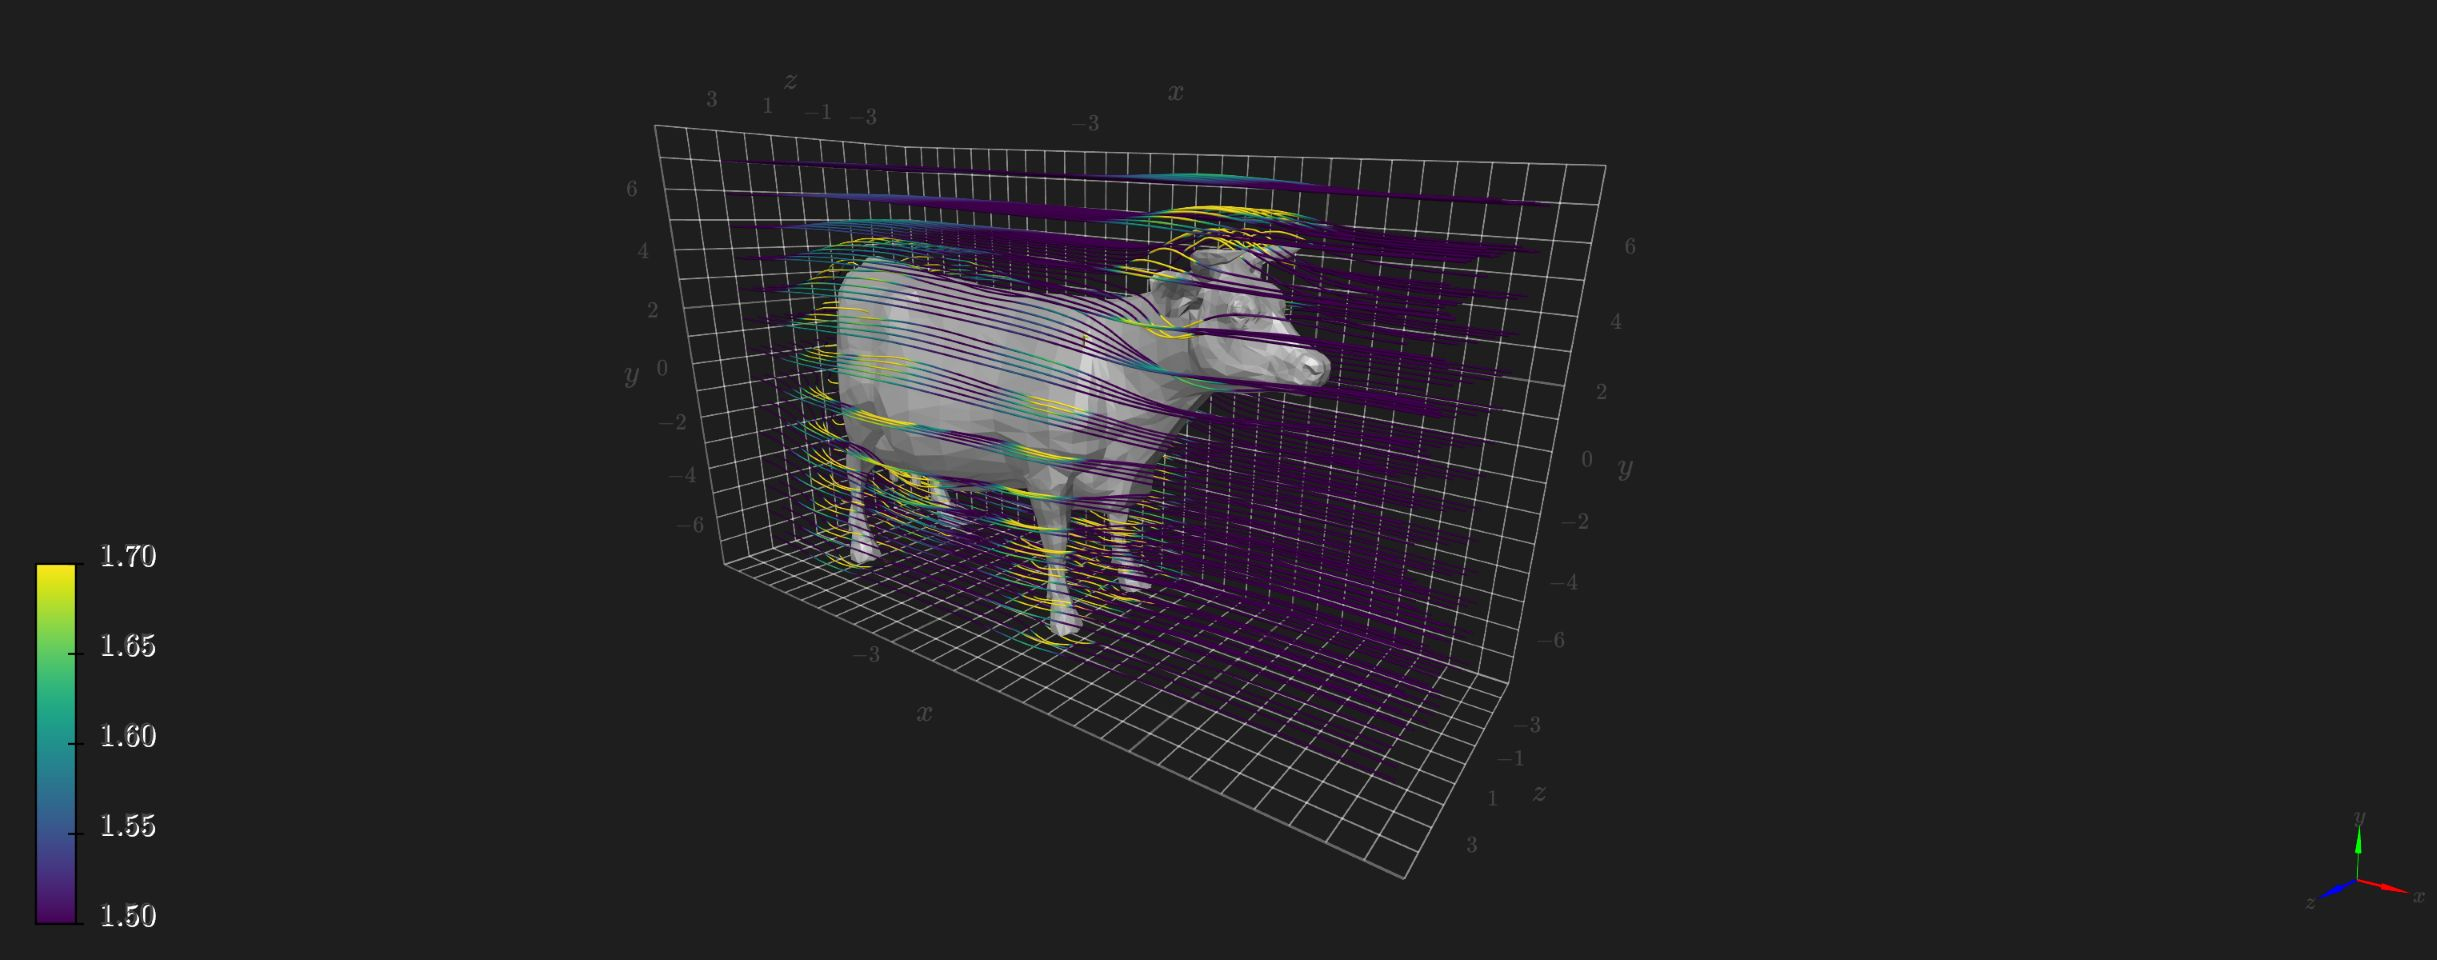